In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MLflow
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# Other 
import joblib
import os

In [2]:
df = pd.read_csv("../data/diamonds_cleaned.csv")

In [3]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53905 entries, 0 to 53904
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53905 non-null  float64
 1   cut      53905 non-null  object 
 2   color    53905 non-null  object 
 3   clarity  53905 non-null  object 
 4   depth    53905 non-null  float64
 5   table    53905 non-null  float64
 6   price    53905 non-null  int64  
 7   x        53905 non-null  float64
 8   y        53905 non-null  float64
 9   z        53905 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
df.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [6]:
X = df.drop("price", axis=1)
y = df["price"]

In [7]:
categorical_cols = X.select_dtypes("object").columns.to_list()
numerical_cols = X.select_dtypes("number").columns.to_list()

In [8]:
print(f"Feature count: {X.shape[1]}")
print(f"Examples count: {X.shape[0]}")
print(f"\nCategorical: {categorical_cols}")
print(f"Numerical: {numerical_cols}")

Feature count: 9
Examples count: 53905

Categorical: ['cut', 'color', 'clarity']
Numerical: ['carat', 'depth', 'table', 'x', 'y', 'z']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]} rows.")
print(f"Test size: {X_test.shape[0]} rows.")

Train size: 43124 rows.
Test size: 10781 rows.


In [10]:
cut_order     = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order   = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

encoder = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), categorical_cols)
    ], remainder="passthrough"
)

pipeline = Pipeline(
    steps=[
        ("encoder", encoder),
        ("scaler", StandardScaler()),
        ("model", SVR())
    ]
)
print(f"Steps: {[step[0] for step in pipeline.steps]}")

Steps: ['encoder', 'scaler', 'model']


In [11]:
param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__epsilon": [0.01, 0.1, 0.5],
    "model__kernel": ["rbf", "linear"]
}

In [12]:
mlflow.set_tracking_uri("sqlite:///..//mlflow.db")
mlflow.set_experiment("diamond-price-prediction")

with mlflow.start_run(run_name="svr-gridsearch"):

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=3,
        scoring="r2",
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    r2_test = r2_score(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)

    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mlflow.log_params(best_params)
    mlflow.log_metrics({
        "r2_test_score": r2_test,
        "r2_train_score": r2_train,
        "r2_diff": r2_test - r2_train,
        "mae": mae,
        "rmse": rmse
    })

    # save the model
    signature = infer_signature(X_train, best_model.predict(X_train))
    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        signature=signature,
        input_example=X_train.iloc[0:3],
        registered_model_name="DiamondPricePredictor"
    )

    os.makedirs("../artifacts", exist_ok=True)
    joblib.dump(best_model, "../artifacts/diamond_model.pkl")
    mlflow.log_artifact("../artifacts/diamond_model.pkl")

    print(f"Best Params: {best_params}")
    print(f"R2 Train: {r2_train:.2f}")
    print(f"R2 Test: {r2_test:.2f}")
    print(f"R2 Diff: {(r2_test-r2_train):.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {rmse:.2f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits


2026/06/27 13:17:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 13:18:13 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Best Params: {'model__C': 100, 'model__epsilon': 0.01, 'model__kernel': 'rbf'}
R2 Train: 0.97
R2 Test: 0.97
R2 Diff: -0.00
MAE: 352.07
MSE: 739.97


Registered model 'DiamondPricePredictor' already exists. Creating a new version of this model...
Created version '2' of model 'DiamondPricePredictor'.


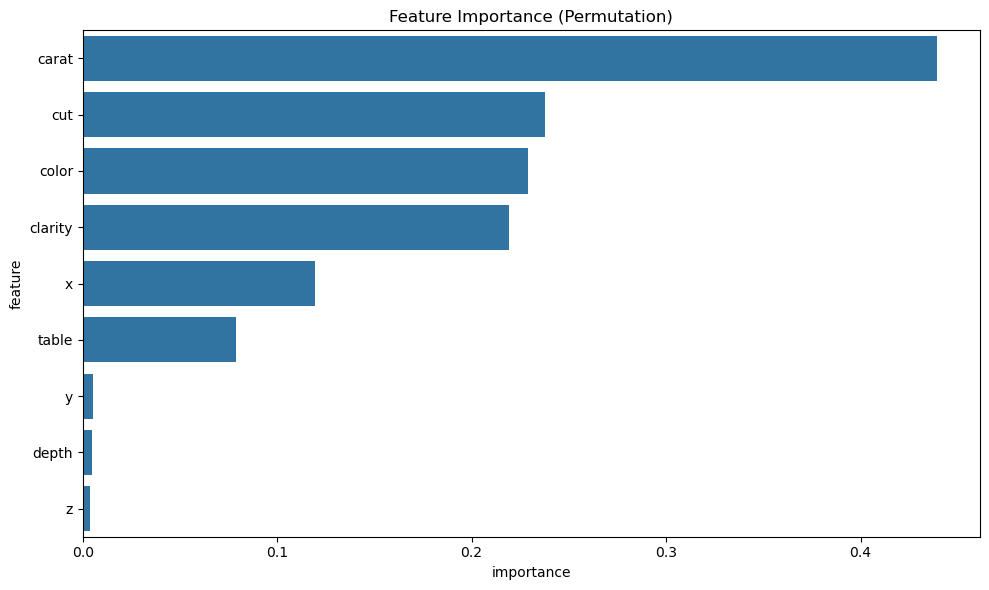

Feature importance saved.


In [23]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_names = numerical_cols + categorical_cols
importance_df = pd.DataFrame({
    "feature"   : feature_names,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Feature Importance (Permutation)")
plt.tight_layout()
plt.savefig("../artifacts/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

mlflow.log_artifact("../artifacts/feature_importance.png")
print("Feature importance saved.")